In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda

img = plt.imread("photo.jpg")
h, w, _ = img.shape
imgLow = (img * 0.4 + 80).astype(np.uint8)
print(img.shape)


(800, 1200, 3)


In [2]:
def make_lut(hist):
    n = hist.sum()
    lut = np.zeros(256, np.uint8)
    c = 0.0
    for i in range(256):
        c = c + hist[i] / n
        lut[i] = int(c * 255 + 0.5)
    return lut


In [3]:
start = time.time()

grayCPU = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        grayCPU[y, x] = (int(imgLow[y, x, 0]) + int(imgLow[y, x, 1]) + int(imgLow[y, x, 2])) // 3

histCPU = np.zeros(256, np.int64)
for y in range(h):
    for x in range(w):
        histCPU[grayCPU[y, x]] += 1

lutCPU = make_lut(histCPU)

eqCPU = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        eqCPU[y, x] = lutCPU[grayCPU[y, x]]

cpuTime = time.time() - start
print("CPU time:", cpuTime, "s")


CPU time: 2.4354970455169678 s


In [4]:
@cuda.jit
def grayscale2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        dst[y, x] = (src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) // 3


@cuda.jit
def local_hist(gray, lhist):
    row = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if row < gray.shape[0]:
        for x in range(gray.shape[1]):
            lhist[row, gray[row, x]] += 1


@cuda.jit
def sum_hist(lhist, hist):
    b = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if b < 256:
        s = 0
        for r in range(lhist.shape[0]):
            s += lhist[r, b]
        hist[b] = s


@cuda.jit
def equalize(src, dst, lut):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        dst[y, x] = lut[src[y, x]]


In [5]:
block = (16, 16)
grid = ((w + 15) // 16, (h + 15) // 16)

devLow = cuda.to_device(imgLow)
devGray = cuda.device_array((h, w), np.uint8)
devHist = cuda.device_array(256, np.int64)
devOut = cuda.device_array((h, w), np.uint8)

def gpu_equalize():
    grayscale2d[grid, block](devLow, devGray)
    devLocal = cuda.to_device(np.zeros((h, 256), np.int32))
    local_hist[(h + 63) // 64, 64](devGray, devLocal)
    sum_hist[1, 256](devLocal, devHist)
    hist = devHist.copy_to_host()
    lut = make_lut(hist)
    equalize[grid, block](devGray, devOut, cuda.to_device(lut))
    cuda.synchronize()
    return hist

histGPU = gpu_equalize()
eqGPU = devOut.copy_to_host()

print("Same histogram as CPU:", np.array_equal(histGPU, histCPU))
print("Max diff with CPU:", np.abs(eqGPU.astype(int) - eqCPU.astype(int)).max())


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 13 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Same histogram as CPU: True
Max diff with CPU: 0


In [6]:
gpu_equalize()
start = time.time()
for r in range(20):
    gpu_equalize()
gpuTime = (time.time() - start) / 20

print("CPU time:", cpuTime, "s")
print("GPU time:", gpuTime, "s")
print("Speedup:", cpuTime / gpuTime)


CPU time: 2.4354970455169678 s
GPU time: 0.001972496509552002 s
Speedup: 1234.728190251715


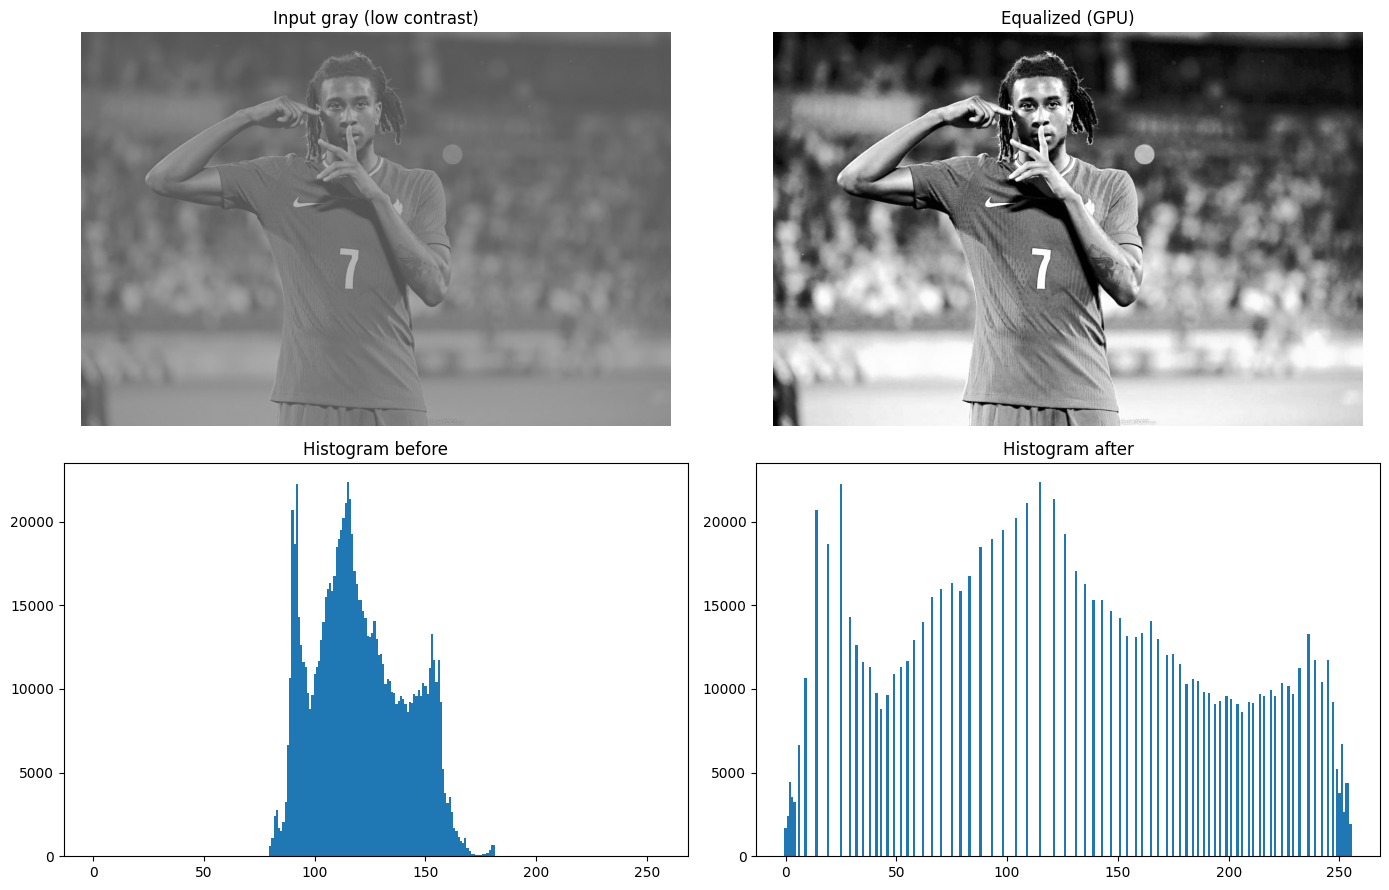

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].imshow(grayCPU, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Input gray (low contrast)")
axes[0, 1].imshow(eqGPU, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Equalized (GPU)")
axes[0, 0].axis("off")
axes[0, 1].axis("off")

axes[1, 0].bar(range(256), histGPU, width=1)
axes[1, 0].set_title("Histogram before")
axes[1, 1].bar(range(256), np.bincount(eqGPU.ravel(), minlength=256), width=1)
axes[1, 1].set_title("Histogram after")

plt.tight_layout()
plt.savefig("results.png")
plt.show()
